# Module 3 — DR Severity Classification (EfficientNet-B0)
**SIH 2026 · Problem Statement 26038 — Explainable AI for Diabetic Retinopathy Screening in Rural India**

Self-contained notebook: preprocessing → dataset → dataloader → EfficientNet-B0 (frozen backbone, train only the 5-class head) → training → evaluation → visualization → checkpoint. A standalone `dr_predictor.py` wraps the trained model for reuse.

**Pipeline:** 4,011 retinal images → aspect-ratio-preserving preprocessing → EfficientNet-B0 (ImageNet, frozen) → 5-class DR grade (0–4) → Referable DR derived from grade ≥ 2.

> **Important:** The ~5% "validation" set is a copy of training images, so all validation metrics are a **Seen-data validation / memorization check** — *not* clinical, independent, or generalization performance. No clinical claims are made from these numbers.

**Run order:** execute cells top to bottom. After **Cell 8**, visually confirm preprocessing looks correct before training. Place `dr_predictor.py` in the model directory before running **Cell 30**.

### Cell 1 — Imports and configuration

**Purpose:** All imports for Module 3 and a single configuration block (paths, image size, ImageNet normalization, referable threshold, training hyper-parameters). Sets all random seeds for reproducibility.

In [ ]:
# ============================================================
# CELL 1 — Imports and configuration
# ============================================================
import os, sys, random, copy, time, importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve, auc, roc_auc_score,
)
from sklearn.preprocessing import label_binarize

%matplotlib inline
sns.set_theme(style="whitegrid")

# ----------------------------- CONFIGURATION (defined once) -----------------------------
CSV_PATH       = Path(r"C:\Users\Arnav Sachdeva\Documents\Data\labels.csv")
IMAGES_DIR     = Path(r"C:\Users\Arnav Sachdeva\Documents\Data\images")
MODEL_DIR      = Path(r"C:\Code\python\Projects\SIH_2\model")
MODEL_PATH     = MODEL_DIR / "efficientnet_b0_dr_best.pth"
PREDICTOR_PATH = MODEL_DIR / "dr_predictor.py"

IMAGE_COLUMN = "id_code"
LABEL_COLUMN = "diagnosis"

NUM_CLASSES  = 5
CLASS_NAMES  = ["Grade 0", "Grade 1", "Grade 2", "Grade 3", "Grade 4"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: name for i, name in enumerate(CLASS_NAMES)}

# ---- Preprocessing ----
IMAGE_SIZE    = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
DARK_TOL      = 7     # grayscale L <= DARK_TOL is treated as black background
PAD_FILL      = 0     # padding colour (black)

# ---- Referable DR ----
REFERABLE_THRESHOLD = 2  # predicted grade >= 2  ->  Referable DR

# ---- Training / reproducibility ----
SEED                     = 42
SEEN_VALIDATION_FRACTION = 0.05      # ~201 SEEN (copied) images -> memorization check
BATCH_SIZE               = 64        # raises RTX workload; lower to 48/32 only if CUDA runs out of memory
NUM_WORKERS              = 0         # Windows + Jupyter safe default (raise to 2 only if your kernel supports it)
PIN_MEMORY               = True
NUM_EPOCHS               = 15
HEAD_LR                  = 1e-3      # fresh classifier learns faster
BACKBONE_LR              = 1e-4      # pretrained features fine-tune gently
WEIGHT_DECAY             = 1e-4
FINE_TUNE_FEATURE_BLOCKS = 4         # unfreeze deeper EfficientNet-B0 stages for real GPU fine-tuning
USE_AMP                  = True      # mixed precision on CUDA improves RTX throughput and lowers VRAM
CHANNELS_LAST            = True      # faster CUDA convolution layout on RTX GPUs

MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------- REPRODUCIBILITY -----------------------------
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)
print("Configuration loaded.")
print("  IMAGE_SIZE =", IMAGE_SIZE, "| NUM_CLASSES =", NUM_CLASSES, "| SEED =", SEED)
print("  CSV_PATH   =", CSV_PATH)
print("  IMAGES_DIR =", IMAGES_DIR)
print("  MODEL_PATH =", MODEL_PATH)

c:\Code\python\Projects\SIH_2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration loaded.
  IMAGE_SIZE = 224 | NUM_CLASSES = 5 | SEED = 42
  CSV_PATH   = C:\Users\Arnav Sachdeva\Documents\Data\labels.csv
  IMAGES_DIR = C:\Users\Arnav Sachdeva\Documents\Data\images
  MODEL_PATH = C:\Code\python\Projects\SIH_2\model\efficientnet_b0_dr_best.pth


### Cell 2 — Load cleaned CSV and resolve image paths

**Purpose:** Reads the cleaned labels.csv and robustly resolves each id_code to a file on disk by filename stem, so .jpg and .png (and ids with/without extension) all resolve.

In [2]:
# ============================================================
# CELL 2 — Load cleaned CSV and resolve image paths (robust, extension-agnostic)
# ============================================================
df = pd.read_csv(CSV_PATH)
assert IMAGE_COLUMN in df.columns, f"{IMAGE_COLUMN!r} not in {df.columns.tolist()}"
assert LABEL_COLUMN in df.columns, f"{LABEL_COLUMN!r} not in {df.columns.tolist()}"

df = df[[IMAGE_COLUMN, LABEL_COLUMN]].copy()
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(int)

# Scan the image directory ONCE and map filename-stem -> full path.
# This resolves ids whether or not id_code carries an extension, and works for .jpg/.png.
VALID_EXT = {".png", ".jpg", ".jpeg"}
stem_index = {}
for p in IMAGES_DIR.iterdir():
    if p.is_file() and p.suffix.lower() in VALID_EXT:
        stem_index.setdefault(p.stem, p)   # first wins; dataset already de-duplicated

def resolve_path(id_code) -> str | None:
    stem = Path(str(id_code)).stem          # strips an extension if the id already has one
    p = stem_index.get(stem)
    return str(p) if p is not None else None

df["image_path"] = df[IMAGE_COLUMN].map(resolve_path)

n_missing = int(df["image_path"].isna().sum())
print(f"CSV rows: {len(df)} | resolved: {df['image_path'].notna().sum()} | unresolved: {n_missing}")
if n_missing:
    print("Unresolved examples:")
    print(df[df["image_path"].isna()].head().to_string())

df = df[df["image_path"].notna()].reset_index(drop=True)
df.head()

CSV rows: 4011 | resolved: 4011 | unresolved: 0


,id_code,diagnosis,image_path
0,train_IDRiD_001,3,C:\Users\Arnav Sachdeva\Documents\Data\images\...
1,train_IDRiD_002,3,C:\Users\Arnav Sachdeva\Documents\Data\images\...
2,train_IDRiD_003,2,C:\Users\Arnav Sachdeva\Documents\Data\images\...
3,train_IDRiD_004,3,C:\Users\Arnav Sachdeva\Documents\Data\images\...
4,train_IDRiD_005,4,C:\Users\Arnav Sachdeva\Documents\Data\images\...


### Cell 3 — Verify dataset and labels

**Purpose:** Computes totals and the per-class distribution FROM the dataframe (not hardcoded) and plots the grade distribution.

Total images: 4011
Total labels: 4011
Unique labels present: [0, 1, 2, 3, 4]

Class distribution (computed, not hardcoded):
  Grade 0:  1963  (48.94%)
  Grade 1:   361  ( 9.00%)
  Grade 2:  1087  (27.10%)
  Grade 3:   268  ( 6.68%)
  Grade 4:   332  ( 8.28%)


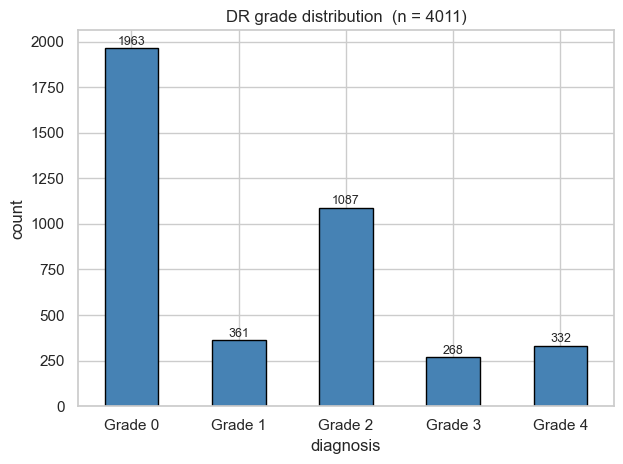

In [3]:
# ============================================================
# CELL 3 — Verify dataset and labels (counts COMPUTED from the dataframe)
# ============================================================
total = len(df)
counts = df[LABEL_COLUMN].value_counts().reindex(range(NUM_CLASSES), fill_value=0).sort_index()

print(f"Total images: {total}")
print(f"Total labels: {int(df[LABEL_COLUMN].notna().sum())}")
print(f"Unique labels present: {sorted(df[LABEL_COLUMN].unique().tolist())}")
print("\nClass distribution (computed, not hardcoded):")
for c in range(NUM_CLASSES):
    n = int(counts[c])
    print(f"  {CLASS_NAMES[c]}: {n:5d}  ({100.0 * n / total:5.2f}%)")

ax = counts.plot(kind="bar", color="steelblue", edgecolor="black")
ax.set_xticklabels(CLASS_NAMES, rotation=0)
ax.set_ylabel("count")
ax.set_title(f"DR grade distribution  (n = {total})")
for i, v in enumerate(counts):
    ax.text(i, v + total * 0.005, str(int(v)), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

### Cell 4 — Device and hardware information

**Purpose:** Selects CUDA if available and prints device, CUDA availability, GPU name/VRAM and library versions.

In [4]:
# ============================================================
# CELL 4 — Device and hardware information
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Selected device :", device)
print("CUDA available  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name        :", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f"Total VRAM      : {props.total_memory / 1e9:.1f} GB")
    print(f"CUDA capability : {props.major}.{props.minor}")
print("torch version   :", torch.__version__)
print("torchvision     :", torchvision.__version__)

Selected device : cuda
CUDA available  : True
GPU name        : NVIDIA GeForce RTX 4050 Laptop GPU
Total VRAM      : 6.4 GB
CUDA capability : 8.9
torch version   : 2.7.0+cu128
torchvision     : 0.22.0+cu128


### Cell 5 — Preprocessing configuration

**Purpose:** Prints a summary of the deterministic, aspect-ratio-preserving preprocessing pipeline and its parameters.

In [5]:
# ============================================================
# CELL 5 — Preprocessing configuration (summary of the pipeline)
# ============================================================
print("EfficientNet-B0 preprocessing configuration")
print("-" * 48)
print("IMAGE_SIZE       :", IMAGE_SIZE, "x", IMAGE_SIZE)
print("Colour           : RGB")
print("Normalize mean   :", IMAGENET_MEAN)
print("Normalize std    :", IMAGENET_STD)
print("Dark-border tol  :", DARK_TOL, " (grayscale L <= tol treated as background)")
print("Pad fill value   :", PAD_FILL, " (black)")
print()
print("Deterministic pipeline (val / inference):")
print("  1. open image           2. convert to RGB")
print("  3. crop near-black border (conservative)")
print("  4. resize longest side -> 224 (ASPECT RATIO PRESERVED)")
print("  5. pad shorter side symmetrically -> 224x224")
print("  6. ToTensor             7. ImageNet Normalize")
print("No stretching / no aspect-ratio distortion is applied.")

EfficientNet-B0 preprocessing configuration
------------------------------------------------
IMAGE_SIZE       : 224 x 224
Colour           : RGB
Normalize mean   : [0.485, 0.456, 0.406]
Normalize std    : [0.229, 0.224, 0.225]
Dark-border tol  : 7  (grayscale L <= tol treated as background)
Pad fill value   : 0  (black)

Deterministic pipeline (val / inference):
  1. open image           2. convert to RGB
  3. crop near-black border (conservative)
  4. resize longest side -> 224 (ASPECT RATIO PRESERVED)
  5. pad shorter side symmetrically -> 224x224
  6. ToTensor             7. ImageNet Normalize
No stretching / no aspect-ratio distortion is applied.


### Cell 6 — Conservative retinal border / background handling

**Purpose:** Defines crop_dark_borders, resize_keep_aspect_pad and the RetinaGeometry transform. Border removal is conservative: only near-black pixels are cropped; nothing above the tolerance is clipped.

In [6]:
# ============================================================
# CELL 6 — Conservative retinal border / background handling
# ============================================================
def crop_dark_borders(img: Image.Image, tol: int = DARK_TOL) -> Image.Image:
    """Conservatively crop near-black borders around the retina.

    A pixel is 'background' only if its grayscale value <= tol. We keep the
    tight bounding box of everything brighter than tol, so retinal anatomy and
    peripheral lesions are never clipped. If detection fails (all black or a
    degenerate box) the original image is returned unchanged.
    """
    gray = np.asarray(img.convert("L"))
    mask = gray > tol
    if not mask.any():
        return img
    ys = np.where(mask.any(axis=1))[0]
    xs = np.where(mask.any(axis=0))[0]
    y0, y1 = int(ys[0]), int(ys[-1]) + 1
    x0, x1 = int(xs[0]), int(xs[-1]) + 1
    if (y1 - y0) < 2 or (x1 - x0) < 2:
        return img
    return img.crop((x0, y0, x1, y1))


def resize_keep_aspect_pad(img: Image.Image, size: int = IMAGE_SIZE, fill: int = PAD_FILL) -> Image.Image:
    """Resize so the LONGEST side == size (aspect ratio preserved), then pad the
    shorter side symmetrically with `fill` to obtain a square size x size image.
    Nothing is cropped, so the full retina (including periphery) is retained.
    """
    w, h = img.size
    scale = size / float(max(w, h))
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    img = img.resize((new_w, new_h), Image.BILINEAR)
    canvas = Image.new("RGB", (size, size), (fill, fill, fill))
    canvas.paste(img, ((size - new_w) // 2, (size - new_h) // 2))
    return canvas


class RetinaGeometry:
    """Deterministic geometric normalization used by BOTH training and inference:
    dark-border crop -> aspect-preserving resize -> pad to square. Returns a PIL
    RGB image of (size, size). (Random augmentation is added separately, on top.)"""

    def __init__(self, size: int = IMAGE_SIZE, tol: int = DARK_TOL, fill: int = PAD_FILL):
        self.size, self.tol, self.fill = size, tol, fill

    def __call__(self, img: Image.Image) -> Image.Image:
        if img.mode != "RGB":
            img = img.convert("RGB")
        img = crop_dark_borders(img, self.tol)
        img = resize_keep_aspect_pad(img, self.size, self.fill)
        return img

print("Preprocessing functions defined: crop_dark_borders, resize_keep_aspect_pad, RetinaGeometry")

Preprocessing functions defined: crop_dark_borders, resize_keep_aspect_pad, RetinaGeometry


### Cell 7 — Training and validation transforms

**Purpose:** validation_transform is deterministic; train_transform adds only mild, medically-reasonable augmentation (small rotation, h-flip, mild translate/scale, mild brightness/contrast).

In [7]:
# ============================================================
# CELL 7 — Training and validation transforms
# ============================================================
retina_geometry = RetinaGeometry(size=IMAGE_SIZE, tol=DARK_TOL, fill=PAD_FILL)

# Deterministic transform for seen-data validation / inference (NO randomness).
validation_transform = transforms.Compose([
    retina_geometry,
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Medically-conservative RANDOM augmentation for training only.
# small rotation + h-flip + mild translation/scaling + mild brightness/contrast.
train_transform = transforms.Compose([
    retina_geometry,                                     # same geometric normalization first
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=15, translate=(0.05, 0.05),
                            scale=(0.95, 1.05), fill=PAD_FILL),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("train_transform      : geometry -> HFlip -> mild Affine(rot=15, trans=0.05, scale=0.95-1.05) -> ColorJitter(0.10) -> tensor -> normalize")
print("validation_transform : geometry -> tensor -> normalize   (DETERMINISTIC)")

train_transform      : geometry -> HFlip -> mild Affine(rot=15, trans=0.05, scale=0.95-1.05) -> ColorJitter(0.10) -> tensor -> normalize
validation_transform : geometry -> tensor -> normalize   (DETERMINISTIC)


### Cell 8 — Visualize ORIGINAL vs PREPROCESSED (required check)

**Purpose:** Shows several images of differing aspect ratios before/after preprocessing. Verify here that geometry is preserved, anatomy is intact and black background is handled BEFORE training.

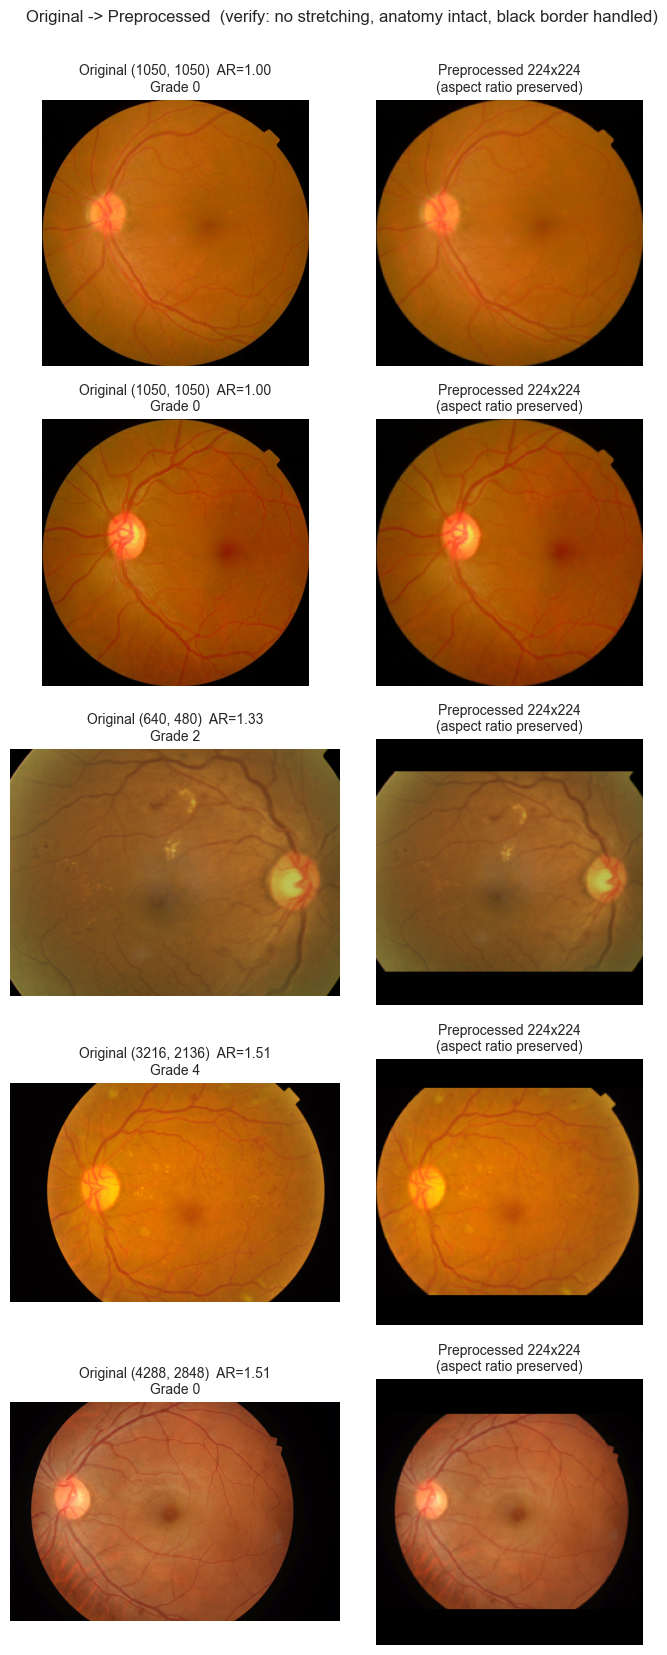

In [8]:
# ============================================================
# CELL 8 — Visualize ORIGINAL vs PREPROCESSED (REQUIRED sanity check)
# ============================================================
# Pick images spanning different aspect ratios so we can confirm the geometry
# is preserved and no retinal anatomy / peripheral lesion is destroyed.
_probe = df.sample(min(300, len(df)), random_state=SEED).copy()
_ars = []
for _p in _probe["image_path"]:
    try:
        with Image.open(_p) as _im:
            _ars.append(_im.size[0] / _im.size[1])
    except Exception:
        _ars.append(np.nan)
_probe["ar"] = _ars
_probe = _probe.dropna(subset=["ar"]).sort_values("ar")

# widest, narrowest, and a mid-aspect sample -> 5 diverse images
picks = pd.concat([_probe.head(2), _probe.iloc[[len(_probe) // 2]], _probe.tail(2)])

n = len(picks)
fig, axes = plt.subplots(n, 2, figsize=(7, 3.3 * n))
for i, (_, r) in enumerate(picks.iterrows()):
    im = Image.open(r["image_path"]).convert("RGB")
    proc = retina_geometry(im)                       # geometry only (viewable, pre-normalization)
    axes[i, 0].imshow(im);   axes[i, 0].axis("off")
    axes[i, 0].set_title(f"Original {im.size}  AR={im.size[0]/im.size[1]:.2f}\n"
                         f"{CLASS_NAMES[int(r[LABEL_COLUMN])]}", fontsize=10)
    axes[i, 1].imshow(proc); axes[i, 1].axis("off")
    axes[i, 1].set_title(f"Preprocessed {IMAGE_SIZE}x{IMAGE_SIZE}\n(aspect ratio preserved)", fontsize=10)
fig.suptitle("Original -> Preprocessed  (verify: no stretching, anatomy intact, black border handled)",
             y=1.002, fontsize=12)
plt.tight_layout(); plt.show()

### Cell 9 — Seen-data validation / memorization-check split

**Purpose:** Trains on ALL unique images; carves a ~5% stratified SEEN subset as a memorization check. This is NOT clinical/independent validation.

In [9]:
# ============================================================
# CELL 9 — Seen-data validation / memorization-check strategy
# ============================================================
# PRIMARY OBJECTIVE: train on essentially ALL unique images.
# The "validation" set is a ~5% STRATIFIED subset that is ALSO in the training
# set (copied / seen). It is therefore a MEMORIZATION CHECK, not real validation.
set_seed(SEED)
_all_idx = np.arange(len(df))
_, seen_val_idx = train_test_split(
    _all_idx,
    test_size=SEEN_VALIDATION_FRACTION,
    stratify=df[LABEL_COLUMN].values,
    random_state=SEED,
)

train_df = df.reset_index(drop=True)                        # ALL unique images
val_df   = df.iloc[seen_val_idx].reset_index(drop=True)     # ~5% SEEN subset

print(f"Train set (all unique images)                 : {len(train_df)}")
print(f"Seen-data validation / memorization check set : {len(val_df)}  "
      f"(~{100 * len(val_df) / len(df):.1f}% of data)")
print("\n>>> These validation images are COPIES of training images.")
print(">>> Metrics on this set are a MEMORIZATION CHECK, NOT clinical / independent validation.")
print("\nSeen-val class counts:",
      val_df[LABEL_COLUMN].value_counts().reindex(range(NUM_CLASSES), fill_value=0).to_dict())

Train set (all unique images)                 : 4011
Seen-data validation / memorization check set : 201  (~5.0% of data)

>>> These validation images are COPIES of training images.
>>> Metrics on this set are a MEMORIZATION CHECK, NOT clinical / independent validation.

Seen-val class counts: {0: 98, 1: 18, 2: 55, 3: 13, 4: 17}


### Cell 10 — Class weights

**Purpose:** Computes balanced class weights from the training labels for weighted CrossEntropyLoss (single imbalance strategy) and prints them.

In [10]:
# ============================================================
# CELL 10 — Class weights for weighted CrossEntropyLoss
# ============================================================
classes_arr = np.arange(NUM_CLASSES)
cw = compute_class_weight(class_weight="balanced",
                          classes=classes_arr,
                          y=train_df[LABEL_COLUMN].values)
class_weights = torch.tensor(cw, dtype=torch.float32)

print("Balanced class weights (used in weighted CrossEntropyLoss):")
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]}: weight = {cw[c]:.4f}")
print("\nStrategy: weighted CrossEntropyLoss ONLY (no sampler / focal / oversampling combined).")

Balanced class weights (used in weighted CrossEntropyLoss):
  Grade 0: weight = 0.4087
  Grade 1: weight = 2.2222
  Grade 2: weight = 0.7380
  Grade 3: weight = 2.9933
  Grade 4: weight = 2.4163

Strategy: weighted CrossEntropyLoss ONLY (no sampler / focal / oversampling combined).


### Cell 11 — Custom PyTorch Dataset

**Purpose:** DRDataset loads an image by path, converts to RGB, applies the transform and returns (tensor, int label).

In [11]:
# ============================================================
# CELL 11 — Custom PyTorch Dataset
# ============================================================
class DRDataset(Dataset):
    """Returns (image_tensor, int_label). Loads from a pre-resolved 'image_path'
    column, converts to RGB, and applies the given transform."""

    def __init__(self, dataframe, transform=None, label_col=LABEL_COLUMN, path_col="image_path"):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col
        self.path_col = path_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row[self.path_col]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = int(row[self.label_col])
        return img, label

print("DRDataset defined.")

DRDataset defined.


### Cell 12 — DataLoaders

**Purpose:** Builds train/validation datasets and loaders with Windows/Jupyter-safe settings (num_workers=0). Runs a one-batch sanity check.

In [12]:
# ============================================================
# CELL 12 — DataLoaders (Windows/Jupyter-safe settings)
# ============================================================
train_dataset      = DRDataset(train_df, transform=train_transform)
validation_dataset = DRDataset(val_df,   transform=validation_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
)
validation_loader = DataLoader(
    validation_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
)

print(f"train_dataset      : {len(train_dataset)} images | train_loader      : {len(train_loader)} batches")
print(f"validation_dataset : {len(validation_dataset)} images | validation_loader : {len(validation_loader)} batches")
print(f"BATCH_SIZE={BATCH_SIZE} | NUM_WORKERS={NUM_WORKERS} (0 = safest on Windows/Jupyter) | PIN_MEMORY={PIN_MEMORY}")

# sanity check on a single batch
_xb, _yb = next(iter(train_loader))
print("one batch ->", _xb.shape, _xb.dtype, "| labels:", _yb.shape, _yb.dtype,
      "| range:", float(_xb.min()), "to", float(_xb.max()))

train_dataset      : 4011 images | train_loader      : 63 batches
validation_dataset : 201 images | validation_loader : 4 batches
BATCH_SIZE=64 | NUM_WORKERS=0 (0 = safest on Windows/Jupyter) | PIN_MEMORY=True
one batch -> torch.Size([64, 3, 224, 224]) torch.float32 | labels: torch.Size([64]) torch.int64 | range: -2.1179039478302 to 2.4285714626312256


### Cell 13 — Load pretrained EfficientNet-B0

**Purpose:** Loads torchvision EfficientNet-B0 with ImageNet weights.

In [13]:
# ============================================================
# CELL 13 — Load pretrained EfficientNet-B0
# ============================================================
effnet_weights = EfficientNet_B0_Weights.IMAGENET1K_V1   # downloaded & cached on first run
model = models.efficientnet_b0(weights=effnet_weights)

print("Loaded EfficientNet-B0 with ImageNet pretrained weights.")
print("Original classifier head:")
print(model.classifier)

Loaded EfficientNet-B0 with ImageNet pretrained weights.
Original classifier head:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


### Cell 14 — Freeze backbone and replace classification head

**Purpose:** Freezes the entire backbone and replaces the final Linear with a 5-logit head. Prints trainable tensors/params to confirm ONLY the head trains.

In [14]:
# ============================================================
# CELL 14 — Fine-tune final EfficientNet blocks + replace the classification head (5 logits)
# ============================================================
# Freeze everything first, then selectively unfreeze the final feature blocks.
for p in model.parameters():
    p.requires_grad = False

# Replace the final Linear layer -> 5 DR grades. New layer is trainable by default.
in_features = model.classifier[1].in_features            # 1280 for EfficientNet-B0
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

# Fine-tune the final EfficientNet feature blocks so the RTX 4050 does meaningful work
# and the model can adapt ImageNet retinal features instead of training only the tiny head.
for block in model.features[-FINE_TUNE_FEATURE_BLOCKS:]:
    for p in block.parameters():
        p.requires_grad = True

for p in model.classifier.parameters():
    p.requires_grad = True

model = model.to(device)
if CHANNELS_LAST and device.type == "cuda":
    model = model.to(memory_format=torch.channels_last)

trainable_names = [n for n, p in model.named_parameters() if p.requires_grad]
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Fine-tuning last {FINE_TUNE_FEATURE_BLOCKS} EfficientNet feature blocks + classifier head.")
print(f"Trainable tensors : {trainable_names[:12]}{' ...' if len(trainable_names) > 12 else ''}")
print(f"Trainable tensor count: {len(trainable_names)}")
print(f"Trainable params  : {n_train:,} / {n_total:,}  ({100 * n_train / n_total:.3f}%)")
print("Model device      :", next(model.parameters()).device)
print("Channels-last    :", bool(CHANNELS_LAST and device.type == "cuda"))


Fine-tuning last 4 EfficientNet feature blocks + classifier head.
Trainable tensors : ['features.5.0.block.0.0.weight', 'features.5.0.block.0.1.weight', 'features.5.0.block.0.1.bias', 'features.5.0.block.1.0.weight', 'features.5.0.block.1.1.weight', 'features.5.0.block.1.1.bias', 'features.5.0.block.2.fc1.weight', 'features.5.0.block.2.fc1.bias', 'features.5.0.block.2.fc2.weight', 'features.5.0.block.2.fc2.bias', 'features.5.0.block.3.0.weight', 'features.5.0.block.3.1.weight'] ...
Trainable tensor count: 109
Trainable params  : 3,705,293 / 4,013,953  (92.310%)
Model device      : cuda:0
Channels-last    : True


### Cell 15 — Loss, optimizer and scheduler

**Purpose:** Weighted CrossEntropyLoss + AdamW (head only) + CosineAnnealingLR.

In [15]:
# ============================================================
# CELL 15 — Loss, optimizer and scheduler
# ============================================================
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))   # weighted for imbalance

backbone_params = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith("classifier.")]
head_params     = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("classifier.")]

optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": BACKBONE_LR},
        {"params": head_params, "lr": HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

amp_enabled = bool(USE_AMP and device.type == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

print("Loss      : weighted CrossEntropyLoss")
print(f"Optimizer : AdamW with BACKBONE_LR={BACKBONE_LR}, HEAD_LR={HEAD_LR}, weight_decay={WEIGHT_DECAY}")
print(f"Scheduler : CosineAnnealingLR (T_max={NUM_EPOCHS})")
print(f"AMP       : {amp_enabled}")


Loss      : weighted CrossEntropyLoss
Optimizer : AdamW with BACKBONE_LR=0.0001, HEAD_LR=0.001, weight_decay=0.0001
Scheduler : CosineAnnealingLR (T_max=15)
AMP       : True


### Cell 16 — Training / validation functions

**Purpose:** run_epoch (train or eval, with live tqdm loss/acc; frozen-backbone BatchNorm kept in eval) and build_checkpoint (rich, self-contained checkpoint for the predictor).

In [16]:
# ============================================================
# CELL 16 — Training / validation functions + checkpoint builder
# ============================================================
def _set_frozen_feature_blocks_eval(model):
    """Keep frozen feature blocks in eval mode while trainable blocks stay in train mode."""
    for block in model.features[:-FINE_TUNE_FEATURE_BLOCKS]:
        block.eval()


def run_epoch(model, loader, criterion, optimizer=None, device=device, desc="Train", scaler=None):
    """One pass over `loader`. If `optimizer` is given -> training, else evaluation.
    tqdm shows live batch progress with running loss & accuracy."""
    is_train = optimizer is not None
    if is_train:
        model.train()
        _set_frozen_feature_blocks_eval(model)
    else:
        model.eval()

    total_loss, correct, seen = 0.0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    bar = tqdm(loader, desc=desc, leave=False)
    with ctx:
        for imgs, labels in bar:
            imgs = imgs.to(device, non_blocking=True)
            if CHANNELS_LAST and device.type == "cuda":
                imgs = imgs.contiguous(memory_format=torch.channels_last)
            labels = labels.to(device, non_blocking=True)
            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=amp_enabled):
                logits = model(imgs)
                loss = criterion(logits, labels)

            if is_train:
                if scaler is not None and scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

            bs = labels.size(0)
            total_loss += loss.item() * bs
            correct += (logits.argmax(1) == labels).sum().item()
            seen += bs
            bar.set_postfix(loss=f"{total_loss/seen:.4f}", acc=f"{correct/seen:.4f}")
    return total_loss / seen, correct / seen


def build_checkpoint(model, history=None, metrics=None, epoch=None):
    """Rich, self-contained checkpoint so dr_predictor.py can rebuild everything."""
    return {
        "arch": "efficientnet_b0",
        "model_state_dict": model.state_dict(),
        "num_classes": NUM_CLASSES,
        "class_names": CLASS_NAMES,
        "class_to_idx": CLASS_TO_IDX,
        "idx_to_class": IDX_TO_CLASS,
        "image_size": IMAGE_SIZE,
        "normalize_mean": IMAGENET_MEAN,
        "normalize_std": IMAGENET_STD,
        "referable_threshold": REFERABLE_THRESHOLD,
        "fine_tune_feature_blocks": FINE_TUNE_FEATURE_BLOCKS,
        "head_lr": HEAD_LR,
        "backbone_lr": BACKBONE_LR,
        "preprocessing": {
            "convert_rgb": True,
            "crop_dark_borders": True,
            "dark_tol": DARK_TOL,
            "resize_mode": "aspect_preserve_pad",
            "pad_fill": PAD_FILL,
            "interpolation": "bilinear",
        },
        "epoch": epoch,
        "history": history,
        "seen_val_metrics": metrics,
        "note": "Validation metrics are a SEEN-DATA memorization check, NOT clinical validation.",
    }

print("run_epoch() and build_checkpoint() defined.")


run_epoch() and build_checkpoint() defined.


### Cell 17 — Run training with tqdm

**Purpose:** Runs the training loop with REAL per-batch tqdm progress, tracks history, and checkpoints the best model by lowest seen-val loss.

In [17]:
# ============================================================
# CELL 17 — Run fine-tuning (REAL tqdm progress over actual batches)
# ============================================================
history = {k: [] for k in ["train_loss", "val_loss", "train_acc", "val_acc", "backbone_lr", "head_lr"]}
best_val_loss, best_epoch = float("inf"), -1

set_seed(SEED)
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available in this notebook kernel. Select the SIH_2 CUDA kernel/interpreter and rerun from Cell 1.")
if next(model.parameters()).device.type != "cuda":
    raise RuntimeError("Model is not on CUDA. Rerun Cell 4, Cell 14, and Cell 15 before Cell 17.")

print("Training device:", device)
print("GPU:", torch.cuda.get_device_name(0))
print("Batch size:", BATCH_SIZE, "| fine-tune feature blocks:", FINE_TUNE_FEATURE_BLOCKS)
print("Trainable params:", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
torch.cuda.reset_peak_memory_stats()

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    epoch_start = time.perf_counter()
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, device, desc="Fine-tuning", scaler=scaler)
    torch.cuda.synchronize()
    va_loss, va_acc = run_epoch(model, validation_loader, criterion, None, device, desc="Seen-Val", scaler=None)
    torch.cuda.synchronize()
    epoch_seconds = time.perf_counter() - epoch_start

    backbone_lr_now = optimizer.param_groups[0]["lr"]
    head_lr_now = optimizer.param_groups[1]["lr"]
    scheduler.step()

    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
    history["backbone_lr"].append(backbone_lr_now); history["head_lr"].append(head_lr_now)

    print(f"  train   loss={tr_loss:.4f}  acc={tr_acc:.4f}")
    print(f"  seen-val loss={va_loss:.4f}  acc={va_acc:.4f}   (memorization check)   "
          f"lr_backbone={backbone_lr_now:.2e}  lr_head={head_lr_now:.2e}")

    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1024**2
        peak = torch.cuda.max_memory_allocated() / 1024**2
        print(f"  cuda memory allocated={used:.0f} MB  peak={peak:.0f} MB  epoch_time={epoch_seconds:.1f}s")

    if va_loss < best_val_loss:
        best_val_loss, best_epoch = va_loss, epoch
        torch.save(build_checkpoint(model, history,
                                    {"val_loss": va_loss, "val_acc": va_acc}, epoch), MODEL_PATH)
        print(f"  * new best (seen-val loss={va_loss:.4f}) -> saved {MODEL_PATH.name}")

print(f"\nDone. Best seen-val loss {best_val_loss:.4f} at epoch {best_epoch}.")
print(f"Best checkpoint: {MODEL_PATH}")


Training device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Batch size: 64 | fine-tune feature blocks: 4
Trainable params: 3,705,293

Epoch 1/15


  train   loss=1.1439  acc=0.6068
  seen-val loss=0.7823  acc=0.7214   (memorization check)   lr_backbone=1.00e-04  lr_head=1.00e-03
  cuda memory allocated=75 MB  peak=999 MB  epoch_time=321.7s
  * new best (seen-val loss=0.7823) -> saved efficientnet_b0_dr_best.pth

Epoch 2/15


  train   loss=0.8456  acc=0.7203
  seen-val loss=0.6430  acc=0.7811   (memorization check)   lr_backbone=9.89e-05  lr_head=9.89e-04
  cuda memory allocated=76 MB  peak=999 MB  epoch_time=298.1s
  * new best (seen-val loss=0.6430) -> saved efficientnet_b0_dr_best.pth

Epoch 3/15


  train   loss=0.7251  acc=0.7669
  seen-val loss=0.5328  acc=0.8557   (memorization check)   lr_backbone=9.57e-05  lr_head=9.57e-04
  cuda memory allocated=76 MB  peak=999 MB  epoch_time=294.9s
  * new best (seen-val loss=0.5328) -> saved efficientnet_b0_dr_best.pth

Epoch 4/15


  train   loss=0.6425  acc=0.7978
  seen-val loss=0.4054  acc=0.8756   (memorization check)   lr_backbone=9.05e-05  lr_head=9.05e-04
  cuda memory allocated=76 MB  peak=999 MB  epoch_time=294.6s
  * new best (seen-val loss=0.4054) -> saved efficientnet_b0_dr_best.pth

Epoch 5/15


...

  train   loss=0.2607  acc=0.9177
  seen-val loss=0.1526  acc=0.9353   (memorization check)   lr_backbone=2.50e-05  lr_head=2.50e-04
  cuda memory allocated=76 MB  peak=999 MB  epoch_time=280.4s
  * new best (seen-val loss=0.1526) -> saved efficientnet_b0_dr_best.pth

Epoch 12/15


  train   loss=0.2366  acc=0.9235
  seen-val loss=0.1350  acc=0.9552   (memorization check)   lr_backbone=1.65e-05  lr_head=1.65e-04
  cuda memory allocated=76 MB  peak=999 MB  epoch_time=285.4s
  * new best (seen-val loss=0.1350) -> saved efficientnet_b0_dr_best.pth

Epoch 13/15


  train   loss=0.2259  acc=0.9332
  seen-val loss=0.1246  acc=0.9602   (memorization check)   lr_backbone=9.55e-06  lr_head=9.55e-05
  cuda memory allocated=76 MB  peak=999 MB  epoch_time=279.9s
  * new best (seen-val loss=0.1246) -> saved efficientnet_b0_dr_best.pth

Epoch 14/15


  train   loss=0.2334  acc=0.9270
  seen-val loss=0.1239  acc=0.9652   (memorization check)   lr_backbone=4.32e-06  lr_head=4.32e-05
  cuda memory allocated=76 MB  peak=999 MB  epoch_time=280.6s
  * new best (seen-val loss=0.1239) -> saved efficientnet_b0_dr_best.pth

Epoch 15/15


  train   loss=0.2265  acc=0.9270
  seen-val loss=0.1209  acc=0.9602   (memorization check)   lr_backbone=1.09e-06  lr_head=1.09e-05
  cuda memory allocated=76 MB  peak=999 MB  epoch_time=280.1s
  * new best (seen-val loss=0.1209) -> saved efficientnet_b0_dr_best.pth

Done. Best seen-val loss 0.1209 at epoch 15.
Best checkpoint: C:\Code\python\Projects\SIH_2\model\efficientnet_b0_dr_best.pth


### Cell 18 — Plot training history

**Purpose:** Training vs seen-data validation loss and accuracy, plus the LR schedule. Clearly labelled as a memorization check.

In [19]:
print(history.keys())

dict_keys(['train_loss', 'val_loss', 'train_acc', 'val_acc', 'backbone_lr', 'head_lr'])


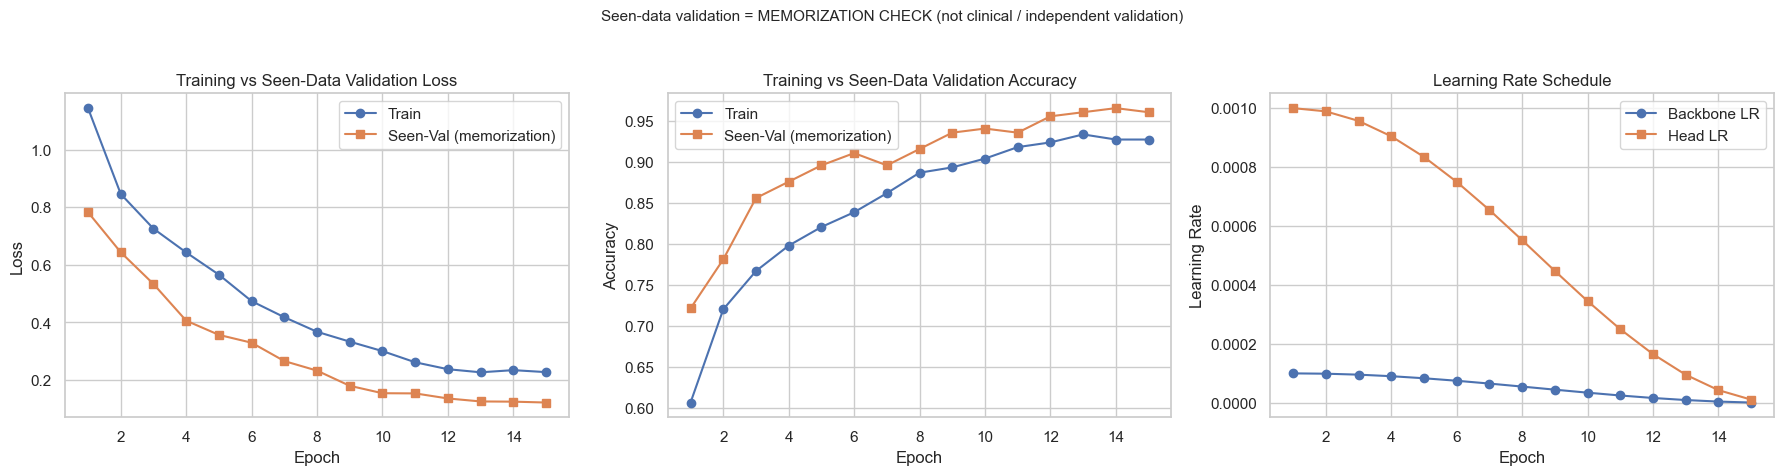

In [20]:
# ============================================================
# CELL 18 — Plot training history (loss / accuracy / lr)
# ============================================================

ep = range(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.6))

# ------------------------------------------------------------
# 1. Loss
# ------------------------------------------------------------
ax[0].plot(ep, history["train_loss"], "-o", label="Train")
ax[0].plot(ep, history["val_loss"], "-s", label="Seen-Val (memorization)")
ax[0].set_title("Training vs Seen-Data Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# ------------------------------------------------------------
# 2. Accuracy
# ------------------------------------------------------------
ax[1].plot(ep, history["train_acc"], "-o", label="Train")
ax[1].plot(ep, history["val_acc"], "-s", label="Seen-Val (memorization)")
ax[1].set_title("Training vs Seen-Data Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

# ------------------------------------------------------------
# 3. Learning Rate
# ------------------------------------------------------------
ax[2].plot(ep, history["backbone_lr"], "-o", label="Backbone LR")
ax[2].plot(ep, history["head_lr"], "-s", label="Head LR")
ax[2].set_title("Learning Rate Schedule")
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("Learning Rate")
ax[2].legend()

fig.suptitle(
    "Seen-data validation = MEMORIZATION CHECK "
    "(not clinical / independent validation)",
    y=1.03,
    fontsize=11
)

plt.tight_layout()
plt.show()

### Cell 19 — Load best checkpoint

**Purpose:** Reloads the best saved checkpoint weights into the model.

In [21]:
# ============================================================
# CELL 19 — Load best checkpoint
# ============================================================
# weights_only=False: this is our OWN trusted checkpoint containing config objects.
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device).eval()

print("Loaded best checkpoint.")
print("  saved at epoch :", ckpt.get("epoch"))
print("  checkpoint keys:", list(ckpt.keys()))

Loaded best checkpoint.
  saved at epoch : 15
  checkpoint keys: ['arch', 'model_state_dict', 'num_classes', 'class_names', 'class_to_idx', 'idx_to_class', 'image_size', 'normalize_mean', 'normalize_std', 'referable_threshold', 'fine_tune_feature_blocks', 'head_lr', 'backbone_lr', 'preprocessing', 'epoch', 'history', 'seen_val_metrics', 'note']


### Cell 20 — Generate predictions and probabilities

**Purpose:** Runs inference on the seen-data set and retains y_true, y_pred, y_prob.

In [22]:
# ============================================================
# CELL 20 — Generate predictions and probabilities (seen-data)
# ============================================================
@torch.no_grad()
def collect_predictions(model, loader, device=device):
    model.eval()
    ys, ps, probs = [], [], []
    for imgs, labels in tqdm(loader, desc="Predicting", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        pr = F.softmax(model(imgs), dim=1).cpu().numpy()
        probs.append(pr)
        ps.append(pr.argmax(axis=1))
        ys.append(labels.numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)

y_true, y_pred, y_prob = collect_predictions(model, validation_loader)
print("Collected (seen-data):")
print("  y_true:", y_true.shape, "| y_pred:", y_pred.shape, "| y_prob:", y_prob.shape)
print("  y_prob rows sum to 1? ->", bool(np.allclose(y_prob.sum(axis=1), 1.0)))

Collected (seen-data):
  y_true: (201,) | y_pred: (201,) | y_prob: (201, 5)
  y_prob rows sum to 1? -> True


### Cell 21 — 5-class metrics

**Purpose:** Accuracy, balanced accuracy, macro/weighted F1, macro precision/recall and the full classification report (zero_division=0).

In [23]:
# ============================================================
# CELL 21 — 5-class metrics  (SEEN-DATA memorization check)
# ============================================================
acc         = accuracy_score(y_true, y_pred)
bal_acc     = balanced_accuracy_score(y_true, y_pred)
macro_f1    = f1_score(y_true, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
macro_prec  = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_rec   = recall_score(y_true, y_pred, average="macro", zero_division=0)

print("=== 5-class metrics  (SEEN-DATA memorization check, NOT clinical validation) ===")
print(f"Accuracy          : {acc:.4f}")
print(f"Balanced accuracy : {bal_acc:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")
print(f"Weighted F1       : {weighted_f1:.4f}")
print(f"Macro precision   : {macro_prec:.4f}")
print(f"Macro recall      : {macro_rec:.4f}\n")
print(classification_report(y_true, y_pred, labels=list(range(NUM_CLASSES)),
                            target_names=CLASS_NAMES, zero_division=0))

=== 5-class metrics  (SEEN-DATA memorization check, NOT clinical validation) ===
Accuracy          : 0.9701
Balanced accuracy : 0.9814
Macro F1          : 0.9642
Weighted F1       : 0.9713
Macro precision   : 0.9527
Macro recall      : 0.9814

              precision    recall  f1-score   support

     Grade 0       1.00      0.98      0.99        98
     Grade 1       0.78      1.00      0.88        18
     Grade 2       0.98      0.93      0.95        55
     Grade 3       1.00      1.00      1.00        13
     Grade 4       1.00      1.00      1.00        17

    accuracy                           0.97       201
   macro avg       0.95      0.98      0.96       201
weighted avg       0.98      0.97      0.97       201



### Cell 22 — Confusion matrix (counts + normalized)

**Purpose:** Raw-count and row-normalized 5-class confusion matrices.

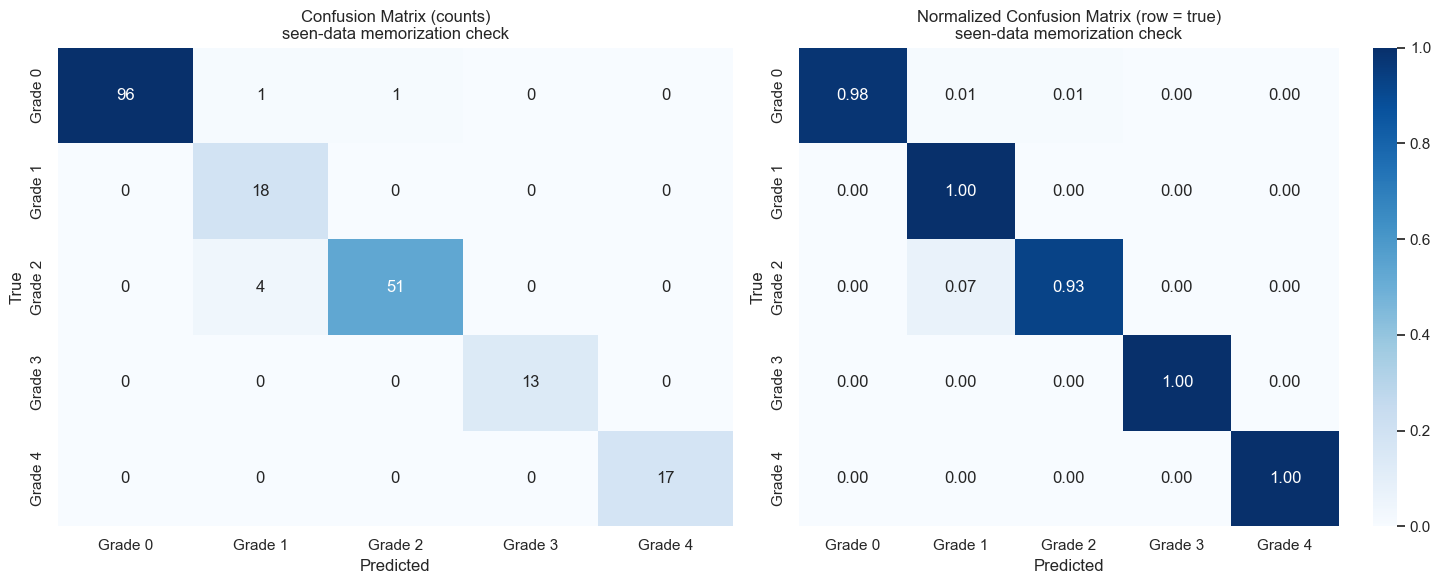

In [24]:
# ============================================================
# CELL 22 — 5-class confusion matrix (raw counts + normalized)
# ============================================================
labels_idx = list(range(NUM_CLASSES))
cm      = confusion_matrix(y_true, y_pred, labels=labels_idx)
cm_norm = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize="true")

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[0], cbar=False)
ax[0].set_title("Confusion Matrix (counts)\nseen-data memorization check")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[1])
ax[1].set_title("Normalized Confusion Matrix (row = true)\nseen-data memorization check")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True")
plt.tight_layout(); plt.show()

### Cell 23 — Per-class precision / recall / F1

**Purpose:** Grouped bar chart of per-class precision, recall and F1 with support counts.

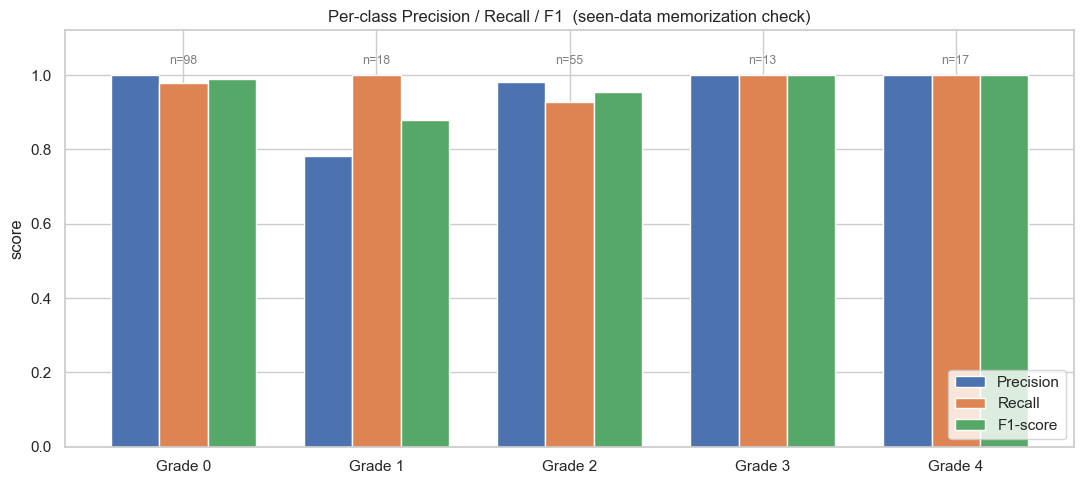

In [25]:
# ============================================================
# CELL 23 — Per-class precision / recall / F1 (grouped bar chart)
# ============================================================
prec_c, rec_c, f1_c, support_c = precision_recall_fscore_support(
    y_true, y_pred, labels=labels_idx, zero_division=0)

x = np.arange(NUM_CLASSES); w = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, prec_c, w, label="Precision")
ax.bar(x,     rec_c,  w, label="Recall")
ax.bar(x + w, f1_c,   w, label="F1-score")
for i in range(NUM_CLASSES):
    ax.text(i, 1.03, f"n={int(support_c[i])}", ha="center", fontsize=9, color="gray")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.12); ax.set_ylabel("score")
ax.set_title("Per-class Precision / Recall / F1  (seen-data memorization check)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### Cell 24 — Multiclass ROC / AUC

**Purpose:** One-vs-rest ROC curves and AUC per class plus macro-average, computed from probabilities (not hard labels).

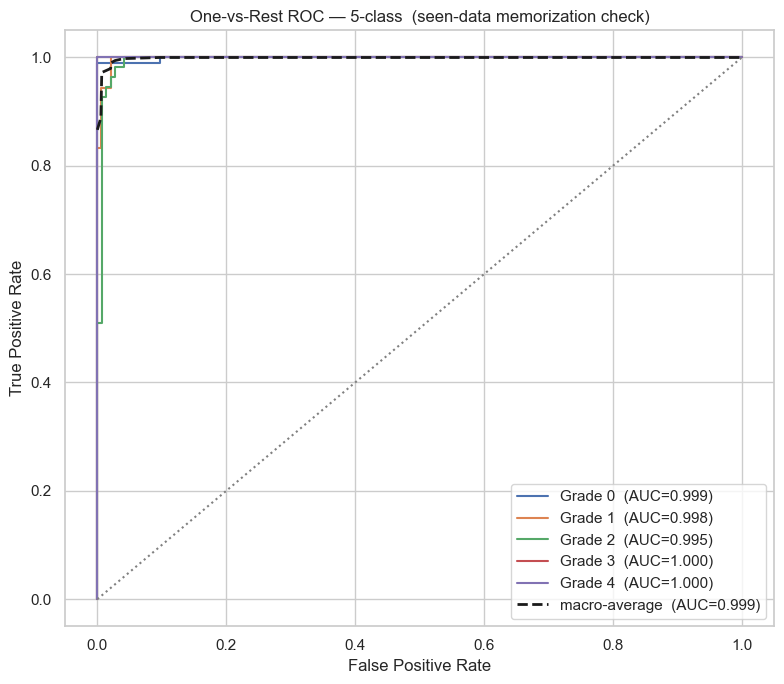

sklearn macro OvR AUC: 0.9985


In [26]:
# ============================================================
# CELL 24 — Multiclass one-vs-rest ROC / AUC (uses probabilities)
# ============================================================
y_bin = label_binarize(y_true, classes=labels_idx)   # shape (n, 5)
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(8, 7))
for i in range(NUM_CLASSES):
    if y_bin[:, i].sum() == 0:            # class absent in this set -> skip
        print(f"[skip] {CLASS_NAMES[i]}: no positive samples in seen-val subset")
        continue
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"{CLASS_NAMES[i]}  (AUC={roc_auc[i]:.3f})")

present = [i for i in range(NUM_CLASSES) if i in fpr]
all_fpr = np.unique(np.concatenate([fpr[i] for i in present]))
mean_tpr = np.zeros_like(all_fpr)
for i in present:
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(present)
macro_auc = auc(all_fpr, mean_tpr)
plt.plot(all_fpr, mean_tpr, "--k", lw=2, label=f"macro-average  (AUC={macro_auc:.3f})")

plt.plot([0, 1], [0, 1], ":", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC — 5-class  (seen-data memorization check)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

try:
    sk_macro = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    print(f"sklearn macro OvR AUC: {sk_macro:.4f}")
except Exception as e:
    print("roc_auc_score note:", e)

### Cell 25 — Referable DR metrics

**Purpose:** Derives Referable DR (grade>=2): sensitivity, specificity, precision, recall, F1, accuracy, ROC-AUC. Compares against SIH TARGETS without claiming clinical performance.

In [27]:
# ============================================================
# CELL 25 — Referable DR metrics (derived from 5-class output; grade >= 2)
# ============================================================
# Referable DR: Grade 0/1 -> Non-referable, Grade 2/3/4 -> Referable.
y_true_ref = (y_true >= REFERABLE_THRESHOLD).astype(int)
y_pred_ref = (y_pred >= REFERABLE_THRESHOLD).astype(int)
referable_prob = y_prob[:, REFERABLE_THRESHOLD:].sum(axis=1)   # P(G2)+P(G3)+P(G4)

tn, fp, fn, tp = confusion_matrix(y_true_ref, y_pred_ref, labels=[0, 1]).ravel()
sensitivity   = tp / (tp + fn) if (tp + fn) else 0.0
specificity   = tn / (tn + fp) if (tn + fp) else 0.0
precision_ref = tp / (tp + fp) if (tp + fp) else 0.0
recall_ref    = sensitivity
f1_ref        = (2 * precision_ref * recall_ref / (precision_ref + recall_ref)
                 if (precision_ref + recall_ref) else 0.0)
accuracy_ref  = (tp + tn) / (tp + tn + fp + fn)
try:
    auc_ref = roc_auc_score(y_true_ref, referable_prob)
except Exception:
    auc_ref = float("nan")

print("=== Referable DR (grade >= 2) — SEEN-DATA memorization check ===")
print(f"Sensitivity (recall) : {sensitivity:.4f}   [SIH target > 0.90]")
print(f"Specificity          : {specificity:.4f}   [SIH target > 0.85]")
print(f"Precision            : {precision_ref:.4f}")
print(f"F1-score             : {f1_ref:.4f}")
print(f"Accuracy             : {accuracy_ref:.4f}")
print(f"ROC-AUC              : {auc_ref:.4f}")
print(f"Counts               : TP={tp} TN={tn} FP={fp} FN={fn}")

met_sens = sensitivity > 0.90
met_spec = specificity > 0.85
print(f"\nTarget check (on SEEN data): sensitivity>0.90 -> {'MET' if met_sens else 'NOT met'} | "
      f"specificity>0.85 -> {'MET' if met_spec else 'NOT met'}")
print(">>> This is a MEMORIZATION CHECK. It is NOT a clinical performance claim.")

=== Referable DR (grade >= 2) — SEEN-DATA memorization check ===
Sensitivity (recall) : 0.9529   [SIH target > 0.90]
Specificity          : 0.9914   [SIH target > 0.85]
Precision            : 0.9878
F1-score             : 0.9701
Accuracy             : 0.9751
ROC-AUC              : 0.9971
Counts               : TP=81 TN=115 FP=1 FN=4

Target check (on SEEN data): sensitivity>0.90 -> MET | specificity>0.85 -> MET
>>> This is a MEMORIZATION CHECK. It is NOT a clinical performance claim.


### Cell 26 — Referable DR confusion matrix

**Purpose:** Binary (Referable vs Non-referable) confusion matrix.

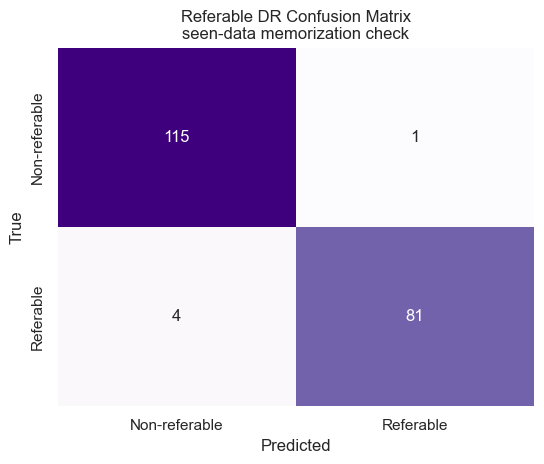

In [28]:
# ============================================================
# CELL 26 — Referable DR binary confusion matrix
# ============================================================
cm_ref = confusion_matrix(y_true_ref, y_pred_ref, labels=[0, 1])
plt.figure(figsize=(5.6, 4.8))
sns.heatmap(cm_ref, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=["Non-referable", "Referable"],
            yticklabels=["Non-referable", "Referable"])
plt.title("Referable DR Confusion Matrix\nseen-data memorization check")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

### Cell 27 — Referable DR ROC

**Purpose:** ROC curve using the referable probability P(G2)+P(G3)+P(G4).

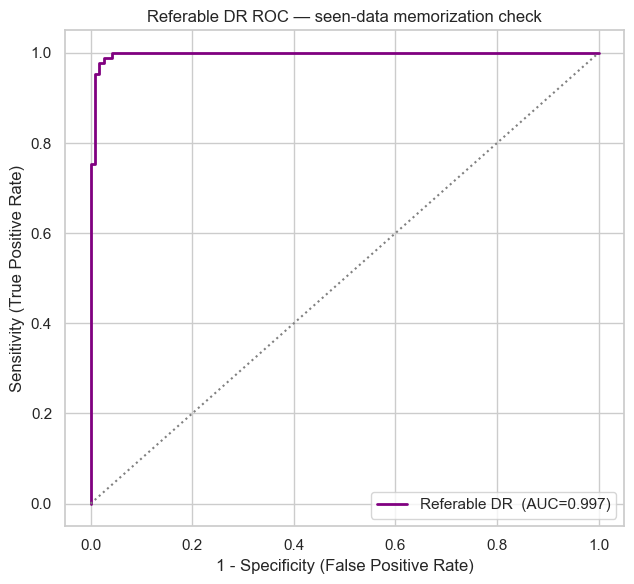

In [29]:
# ============================================================
# CELL 27 — Referable DR ROC curve (uses referable probability)
# ============================================================
fpr_r, tpr_r, _ = roc_curve(y_true_ref, referable_prob)
plt.figure(figsize=(6.5, 6))
plt.plot(fpr_r, tpr_r, color="purple", lw=2, label=f"Referable DR  (AUC={auc_ref:.3f})")
plt.plot([0, 1], [0, 1], ":", color="gray")
plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("Referable DR ROC — seen-data memorization check")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

### Cell 28 — Referable DR metric visualization

**Purpose:** Bar chart of sensitivity/specificity/precision/recall/F1 with target reference lines.

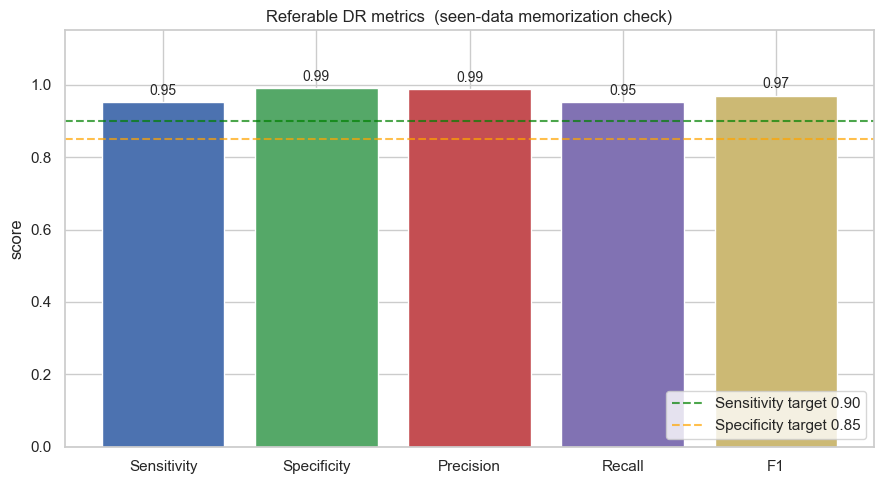

In [30]:
# ============================================================
# CELL 28 — Referable DR metric visualization
# ============================================================
mvals = {"Sensitivity": sensitivity, "Specificity": specificity,
         "Precision": precision_ref, "Recall": recall_ref, "F1": f1_ref}
colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b3", "#ccb974"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(list(mvals.keys()), list(mvals.values()), color=colors)
for b, v in zip(bars, mvals.values()):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
ax.axhline(0.90, ls="--", color="green",  alpha=0.7, label="Sensitivity target 0.90")
ax.axhline(0.85, ls="--", color="orange", alpha=0.7, label="Specificity target 0.85")
ax.set_ylim(0, 1.15); ax.set_ylabel("score")
ax.set_title("Referable DR metrics  (seen-data memorization check)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### Cell 29 — Save / verify final model checkpoint

**Purpose:** Re-saves the rich checkpoint (with final seen-data metrics) and verifies all required keys are present by reloading.

In [31]:
# ============================================================
# CELL 29 — Save / verify final model checkpoint
# ============================================================
final_metrics = {
    "accuracy": float(acc),
    "balanced_accuracy": float(bal_acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "referable_sensitivity": float(sensitivity),
    "referable_specificity": float(specificity),
    "referable_auc": float(auc_ref),
    "measured_on": "seen-data memorization check",
}
torch.save(build_checkpoint(model, history, final_metrics, ckpt.get("epoch")), MODEL_PATH)

# verify by reloading
_v = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
required = ["arch", "model_state_dict", "num_classes", "class_names", "class_to_idx",
            "idx_to_class", "image_size", "normalize_mean", "normalize_std",
            "referable_threshold", "preprocessing"]
missing_keys = [k for k in required if k not in _v]

print("Saved checkpoint ->", MODEL_PATH)
print(f"File size        : {MODEL_PATH.stat().st_size / 1e6:.2f} MB")
print("Missing required keys:", missing_keys if missing_keys else "none  (all present)")
print("Checkpoint keys  :", list(_v.keys()))
print("Preprocessing cfg:", _v["preprocessing"])

Saved checkpoint -> C:\Code\python\Projects\SIH_2\model\efficientnet_b0_dr_best.pth
File size        : 16.36 MB
Missing required keys: none  (all present)
Checkpoint keys  : ['arch', 'model_state_dict', 'num_classes', 'class_names', 'class_to_idx', 'idx_to_class', 'image_size', 'normalize_mean', 'normalize_std', 'referable_threshold', 'fine_tune_feature_blocks', 'head_lr', 'backbone_lr', 'preprocessing', 'epoch', 'history', 'seen_val_metrics', 'note']
Preprocessing cfg: {'convert_rgb': True, 'crop_dark_borders': True, 'dark_tol': 7, 'resize_mode': 'aspect_preserve_pad', 'pad_fill': 0, 'interpolation': 'bilinear'}


### Cell 30 — Load and test DRPredictor

**Purpose:** Imports the standalone dr_predictor.py from the model directory and runs a smoke-test prediction.

In [33]:
# ============================================================
# CELL 30 — Load and test the standalone DRPredictor
# ============================================================
# Requires dr_predictor.py to be present in MODEL_DIR (delivered alongside this notebook).
if not PREDICTOR_PATH.exists():
    raise FileNotFoundError(
        f"dr_predictor.py not found in {MODEL_DIR}. "
        f"Place dr_predictor.py there (same folder as the .pth) and re-run this cell."
    )

if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))
import model.dr_predictor as dr_predictor
importlib.reload(dr_predictor)             # pick up latest version if edited
from model.dr_predictor import DRPredictor

predictor = DRPredictor(model_path=str(MODEL_PATH))

# smoke test on one seen image
_sample_path = val_df.iloc[0]["image_path"]
_result = predictor.predict(_sample_path)
print("DRPredictor loaded. Example output:")
for k, v in _result.items():
    print(f"  {k}: {v}")

DRPredictor loaded. Example output:
  predicted_grade: 0
  predicted_label: Grade 0
  probabilities: {'Grade 0': 0.9986729621887207, 'Grade 1': 0.0008548959740437567, 'Grade 2': 0.0004237861721776426, 'Grade 3': 2.5958734113373794e-05, 'Grade 4': 2.235065767308697e-05}
  referable_dr: False
  referable_probability: 0.00047209556214511395


### Cell 31 — Example prediction visualization

**Purpose:** Displays several images with predicted grade, all five class probabilities and referable status. Model demonstration only — not clinical validation.

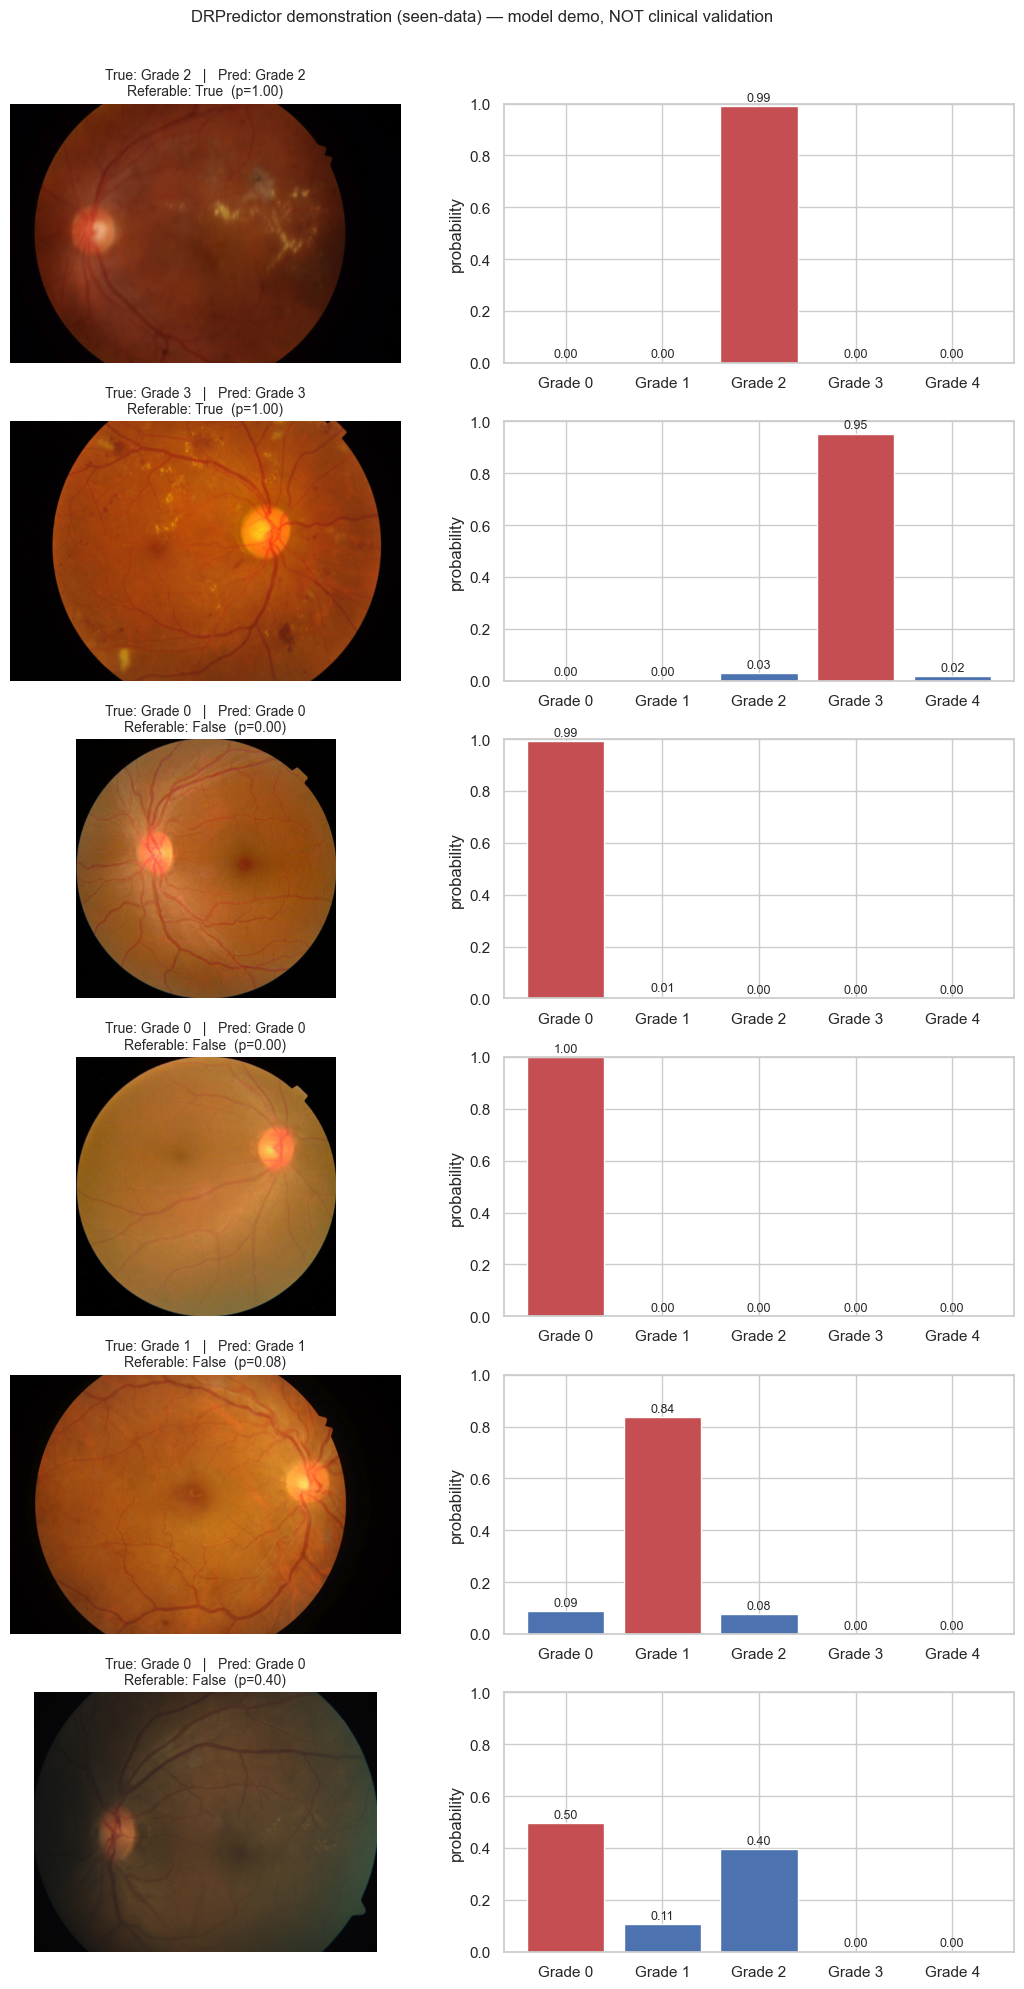

In [34]:
# ============================================================
# CELL 31 — Example prediction visualization (image + class probabilities)
# ============================================================
show_df = val_df.sample(min(6, len(val_df)), random_state=SEED).reset_index(drop=True)
n = len(show_df)
fig, axes = plt.subplots(n, 2, figsize=(11, 3.3 * n))
if n == 1:
    axes = axes.reshape(1, 2)

for i in range(n):
    row = show_df.iloc[i]
    res = predictor.predict(row["image_path"])
    img = Image.open(row["image_path"]).convert("RGB")

    axes[i, 0].imshow(img); axes[i, 0].axis("off")
    axes[i, 0].set_title(
        f"True: {CLASS_NAMES[int(row[LABEL_COLUMN])]}   |   Pred: {res['predicted_label']}\n"
        f"Referable: {res['referable_dr']}  (p={res['referable_probability']:.2f})",
        fontsize=10)

    probs = [res["probabilities"][c] for c in CLASS_NAMES]
    bar_colors = ["#c44e52" if c == res["predicted_label"] else "#4c72b0" for c in CLASS_NAMES]
    axes[i, 1].bar(CLASS_NAMES, probs, color=bar_colors)
    axes[i, 1].set_ylim(0, 1); axes[i, 1].set_ylabel("probability")
    for j, pv in enumerate(probs):
        axes[i, 1].text(j, pv + 0.02, f"{pv:.2f}", ha="center", fontsize=9)

fig.suptitle("DRPredictor demonstration (seen-data) — model demo, NOT clinical validation",
             y=1.004, fontsize=12)
plt.tight_layout(); plt.show()